In [4]:
# Import required libraries
import pandas as pd
import os

# Define base path
BASE_PATH = "../data/processed"

# Load all processed files
deaths_df = pd.read_csv(os.path.join(BASE_PATH, "total_accidental_deaths_2015_2022.csv"))
transport_df = pd.read_csv(os.path.join(BASE_PATH, "mode_of_transport_2015_2022.csv"))
month_df = pd.read_csv(os.path.join(BASE_PATH, "month_of_occurrence_2015_2022.csv"))
time_df = pd.read_csv(os.path.join(BASE_PATH, "time_of_occurrence_2015_2022.csv"))
road_df = pd.read_csv(os.path.join(BASE_PATH, "road_classification_2015_2022.csv"))
place_df = pd.read_csv(os.path.join(BASE_PATH, "place_of_occurrence_2015_2022.csv"))

print("All files loaded successfully!")
print(f"\nDeaths df shape: {deaths_df.shape}")
print(f"Transport df shape: {transport_df.shape}")
print(f"Month df shape: {month_df.shape}")
print(f"Time df shape: {time_df.shape}")
print(f"Road df shape: {road_df.shape}")
print(f"Place df shape: {place_df.shape}")

All files loaded successfully!

Deaths df shape: (280, 4)
Transport df shape: (280, 10)
Month df shape: (280, 15)
Time df shape: (280, 11)
Road df shape: (280, 8)
Place df shape: (280, 19)


In [5]:
# Check which State/UT and Year is missing in deaths_df
full_combinations = pd.MultiIndex.from_product(
    [deaths_df["State/UT"].unique(), range(2015, 2023)],
    names=["State/UT", "Year"]
)

existing_combinations = pd.MultiIndex.from_frame(deaths_df[["State/UT", "Year"]])
missing = full_combinations.difference(existing_combinations)
print(f"Missing combinations: {list(missing)}")

Missing combinations: []


In [6]:
# Check which State/UT and Year is missing in time_df
full_combinations = pd.MultiIndex.from_product(
    [time_df["State/UT"].unique(), range(2015, 2023)],
    names=["State/UT", "Year"]
)

existing_combinations = pd.MultiIndex.from_frame(time_df[["State/UT", "Year"]])
missing = full_combinations.difference(existing_combinations)
print(f"Missing combinations: {list(missing)}")

Missing combinations: []


In [7]:
# Data Overview - Missing values and basic stats
import pandas as pd

dataframes = {
    "Total Accidental Deaths": deaths_df,
    "Mode of Transport": transport_df,
    "Month of Occurrence": month_df,
    "Time of Occurrence": time_df,
    "Road Classification": road_df,
    "Place of Occurrence": place_df
}

for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    print(f"Missing Values: {df.isnull().sum().sum()}")
    print(f"Data Types:\n{df.dtypes}")
    print(f"\nBasic Stats:")
    print(df.describe())


Dataset: Total Accidental Deaths
Shape: (280, 4)
Missing Values: 0
Data Types:
S.No.                      int64
State/UT                     str
Year                       int64
Total Accidental Deaths    int64
dtype: object

Basic Stats:
            S.No.        Year  Total Accidental Deaths
count  280.000000   280.00000               280.000000
mean   140.500000  2018.50000             11323.714286
std     80.973247     2.29539             14275.453231
min      1.000000  2015.00000                 3.000000
25%     70.750000  2016.75000               402.000000
50%    140.500000  2018.50000              5044.000000
75%    210.250000  2020.25000             16913.250000
max    280.000000  2022.00000             70329.000000

Dataset: Mode of Transport
Shape: (280, 10)
Missing Values: 0
Data Types:
S.No.                                 int64
State/UT                                str
Year                                  int64
Truck/Lorry/Mini Truck - Died         int64
Bus - Died    

In [8]:
# Check if matplotlib and seaborn are installed
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("Libraries available!")
except ImportError:
    print("Installing...")
    import subprocess
    subprocess.run(["pip", "install", "matplotlib", "seaborn"])
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("Installed and imported!")

Installing...
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_10_13_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_10_13_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_10_13_x86_64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_10_13_x86_64.whl (293 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_x86_64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp3


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Installed and imported!


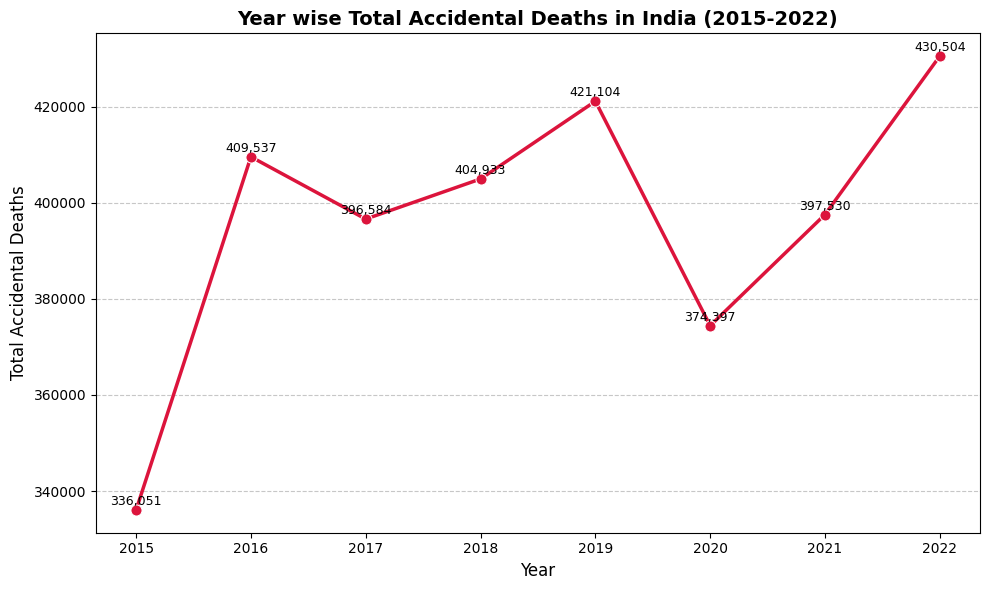


Year wise data:
   Year  Total Accidental Deaths
0  2015                   336051
1  2016                   409537
2  2017                   396584
3  2018                   404933
4  2019                   421104
5  2020                   374397
6  2021                   397530
7  2022                   430504


In [9]:
# Year wise Total Accidental Deaths - India Level
yearly_deaths = deaths_df.groupby("Year")["Total Accidental Deaths"].sum().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_deaths, x="Year", y="Total Accidental Deaths", 
             marker="o", linewidth=2.5, color="crimson", markersize=8)

# Add value labels on each point
for i, row in yearly_deaths.iterrows():
    plt.text(row["Year"], row["Total Accidental Deaths"] + 1000, 
             f"{int(row['Total Accidental Deaths']):,}", 
             ha="center", fontsize=9)

plt.title("Year wise Total Accidental Deaths in India (2015-2022)", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Accidental Deaths", fontsize=12)
plt.xticks(range(2015, 2023))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("\nYear wise data:")
print(yearly_deaths)

/var/folders/lx/xjnsk4q17yz2rmv4g3x38n3r0000gn/T/ipykernel_72684/3434258039.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=top10, x="Average Deaths", y="State/UT",


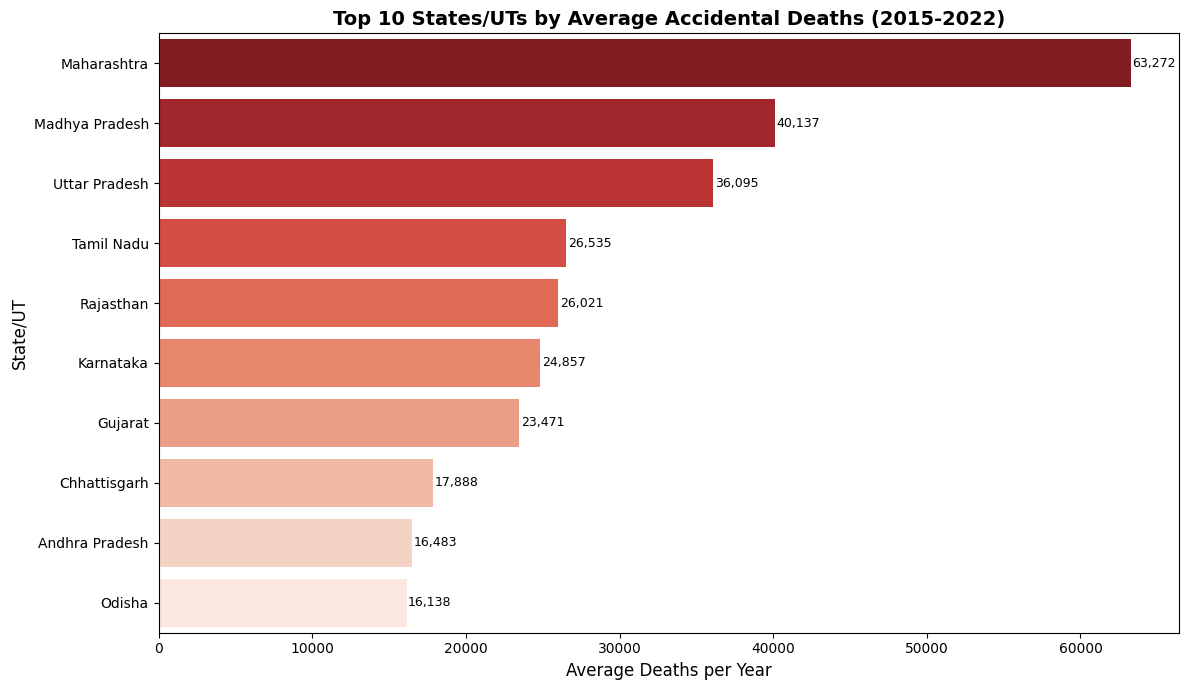


Top 10 States/UTs:
      State/UT  Average Deaths
   Maharashtra       63272.000
Madhya Pradesh       40137.250
 Uttar Pradesh       36095.375
    Tamil Nadu       26535.875
     Rajasthan       26021.250
     Karnataka       24857.750
       Gujarat       23471.875
  Chhattisgarh       17888.125
Andhra Pradesh       16483.375
        Odisha       16138.625


In [10]:
# State wise Average Accidental Deaths (2015-2022)
state_avg = deaths_df.groupby("State/UT")["Total Accidental Deaths"].mean().reset_index()
state_avg.columns = ["State/UT", "Average Deaths"]
state_avg = state_avg.sort_values("Average Deaths", ascending=False).reset_index(drop=True)

# Top 10 states
top10 = state_avg.head(10)

# Plot
plt.figure(figsize=(12, 7))
bars = sns.barplot(data=top10, x="Average Deaths", y="State/UT", 
                   palette="Reds_r")

# Add value labels
for i, row in top10.iterrows():
    plt.text(row["Average Deaths"] + 100, i, 
             f"{int(row['Average Deaths']):,}", 
             va="center", fontsize=9)

plt.title("Top 10 States/UTs by Average Accidental Deaths (2015-2022)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Average Deaths per Year", fontsize=12)
plt.ylabel("State/UT", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 States/UTs:")
print(top10.to_string(index=False))

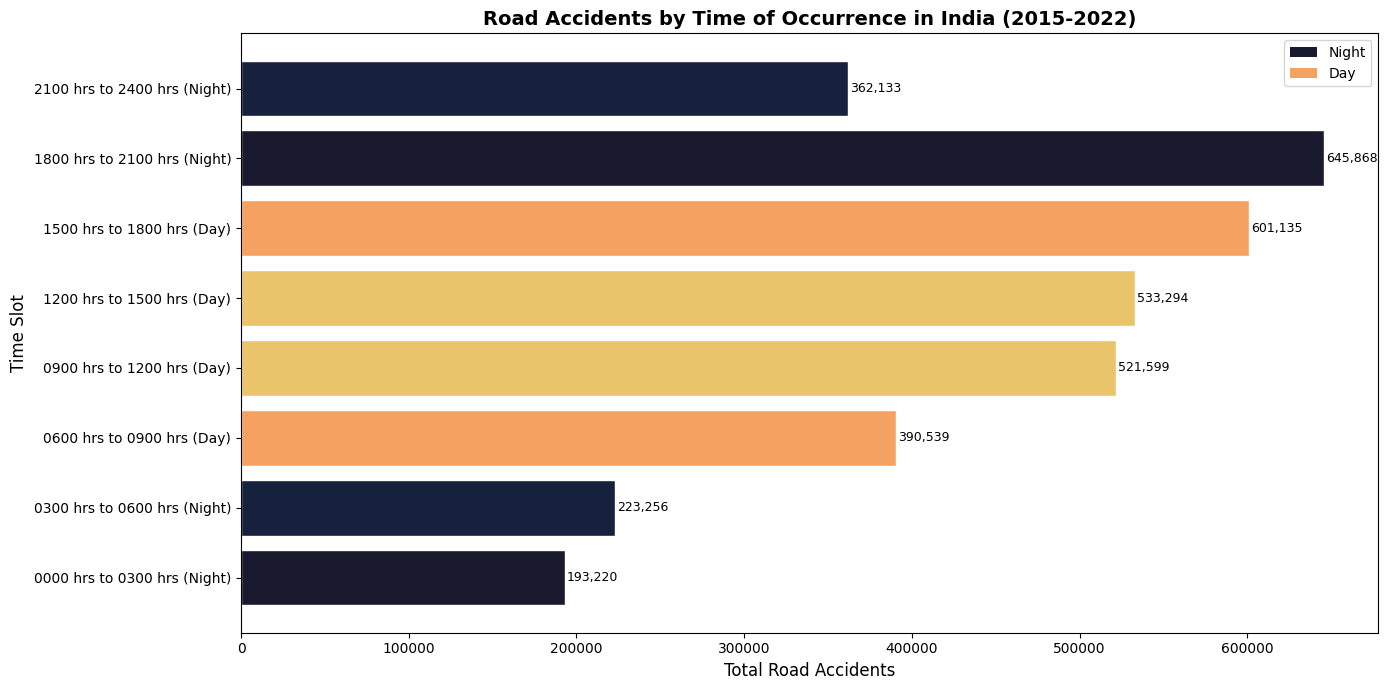


Time slot wise totals:
                   Time Slot  Total Accidents
0000 hrs to 0300 hrs (Night)           193220
0300 hrs to 0600 hrs (Night)           223256
  0600 hrs to 0900 hrs (Day)           390539
  0900 hrs to 1200 hrs (Day)           521599
  1200 hrs to 1500 hrs (Day)           533294
  1500 hrs to 1800 hrs (Day)           601135
1800 hrs to 2100 hrs (Night)           645868
2100 hrs to 2400 hrs (Night)           362133


In [11]:
# Time of Occurrence Analysis - Dark Hours
time_cols = [
    "0000 hrs to 0300 hrs (Night)",
    "0300 hrs to 0600 hrs (Night)",
    "0600 hrs to 0900 hrs (Day)",
    "0900 hrs to 1200 hrs (Day)",
    "1200 hrs to 1500 hrs (Day)",
    "1500 hrs to 1800 hrs (Day)",
    "1800 hrs to 2100 hrs (Night)",
    "2100 hrs to 2400 hrs (Night)"
]

# Total accidents per time slot
time_totals = time_df[time_cols].sum().reset_index()
time_totals.columns = ["Time Slot", "Total Accidents"]

# Define colors — Night = dark, Day = light
colors = ["#1a1a2e", "#16213e", "#f4a261", "#e9c46a", 
          "#e9c46a", "#f4a261", "#1a1a2e", "#16213e"]

# Plot
plt.figure(figsize=(14, 7))
bars = plt.barh(time_totals["Time Slot"], time_totals["Total Accidents"], 
                color=colors, edgecolor="white")

# Add value labels
for bar, val in zip(bars, time_totals["Total Accidents"]):
    plt.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va="center", fontsize=9)

plt.title("Road Accidents by Time of Occurrence in India (2015-2022)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Total Road Accidents", fontsize=12)
plt.ylabel("Time Slot", fontsize=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#1a1a2e", label="Night"),
                   Patch(facecolor="#f4a261", label="Day")]
plt.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

print("\nTime slot wise totals:")
print(time_totals.to_string(index=False))

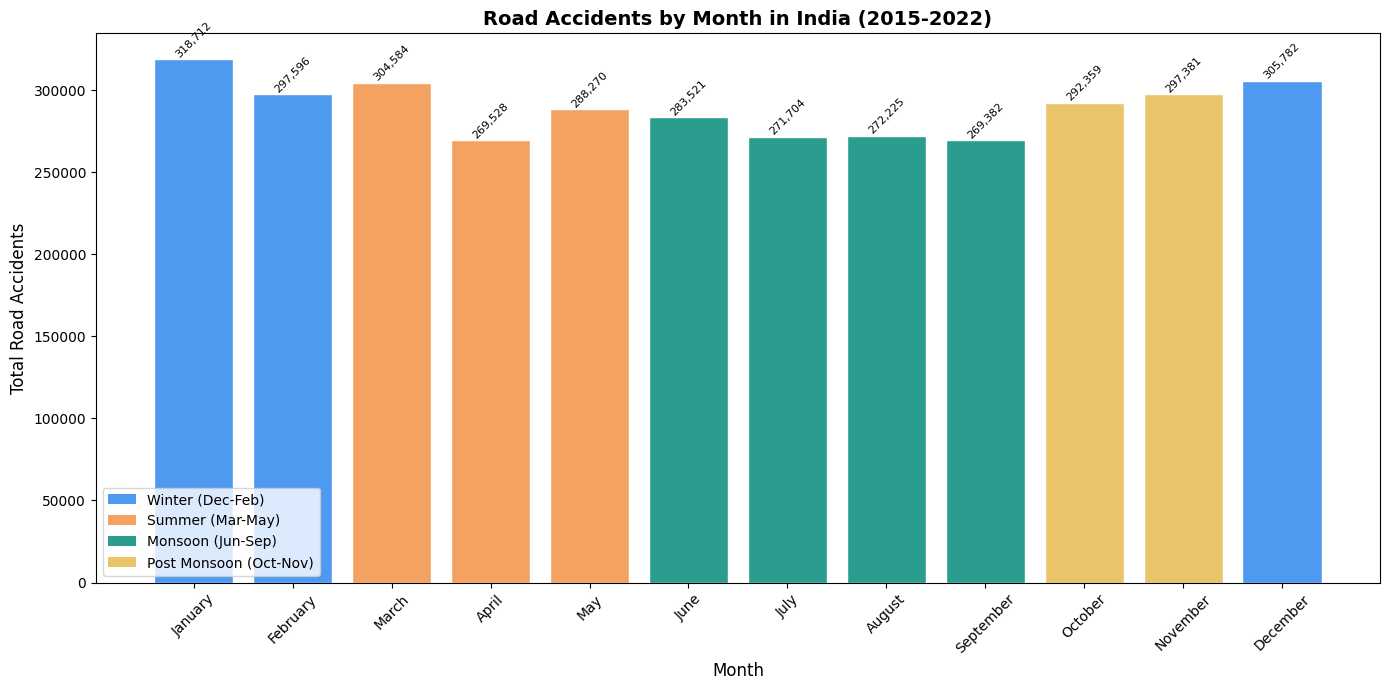


Month wise totals:
    Month  Total Accidents
  January           318712
 February           297596
    March           304584
    April           269528
      May           288270
     June           283521
     July           271704
   August           272225
September           269382
  October           292359
 November           297381
 December           305782


In [12]:
# Month wise Analysis
month_cols = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]

# Total accidents per month
month_totals = month_df[month_cols].sum().reset_index()
month_totals.columns = ["Month", "Total Accidents"]

# Season colors
# Winter: Dec, Jan, Feb — blue
# Summer: Mar, Apr, May — orange
# Monsoon: Jun, Jul, Aug, Sep — green
# Post Monsoon: Oct, Nov — yellow
season_colors = {
    "January": "#4e9af1", "February": "#4e9af1",
    "March": "#f4a261", "April": "#f4a261", "May": "#f4a261",
    "June": "#2a9d8f", "July": "#2a9d8f", "August": "#2a9d8f", "September": "#2a9d8f",
    "October": "#e9c46a", "November": "#e9c46a",
    "December": "#4e9af1"
}

colors = [season_colors[m] for m in month_totals["Month"]]

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(month_totals["Month"], month_totals["Total Accidents"],
               color=colors, edgecolor="white")

# Add value labels
for bar, val in zip(bars, month_totals["Total Accidents"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1000,
             f"{int(val):,}", ha="center", fontsize=8, rotation=45)

plt.title("Road Accidents by Month in India (2015-2022)",
          fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Road Accidents", fontsize=12)
plt.xticks(rotation=45)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4e9af1", label="Winter (Dec-Feb)"),
    Patch(facecolor="#f4a261", label="Summer (Mar-May)"),
    Patch(facecolor="#2a9d8f", label="Monsoon (Jun-Sep)"),
    Patch(facecolor="#e9c46a", label="Post Monsoon (Oct-Nov)")
]
plt.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

print("\nMonth wise totals:")
print(month_totals.to_string(index=False))

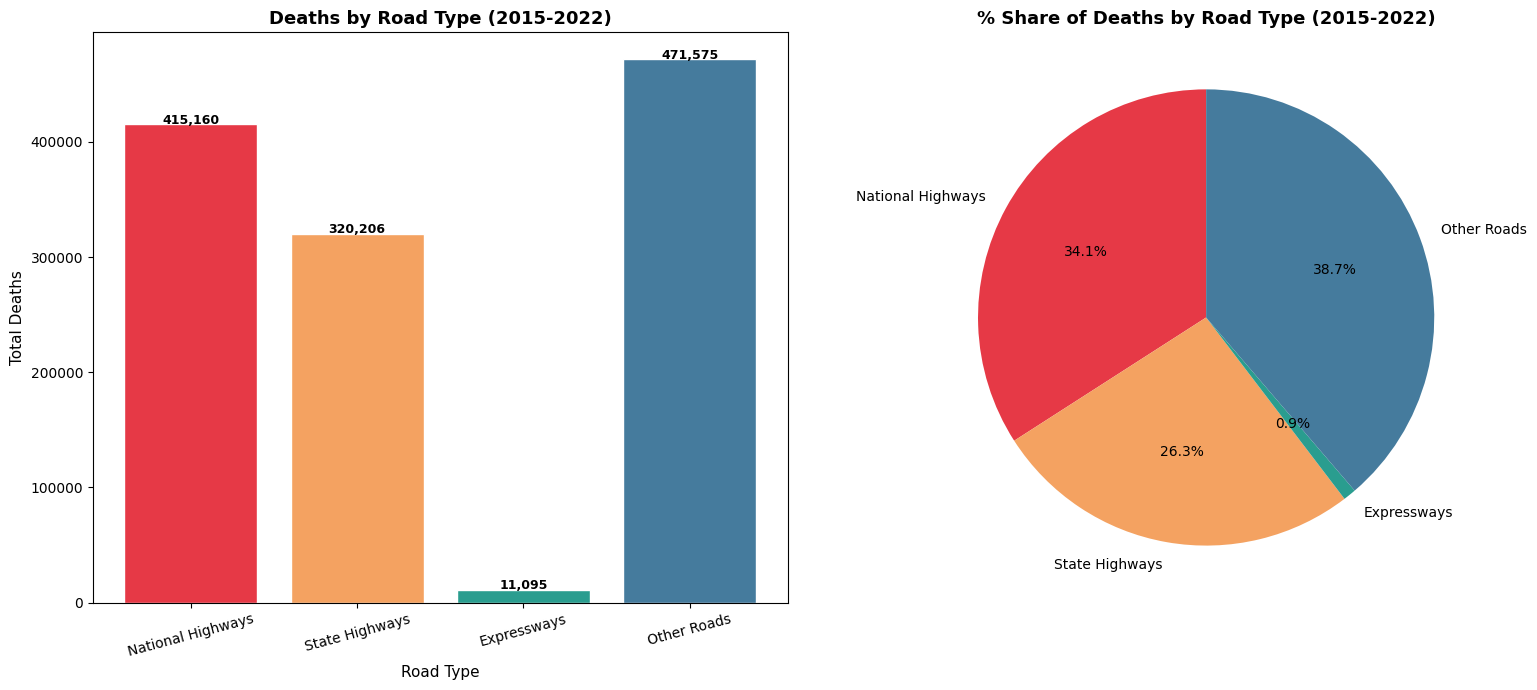


Road type wise totals:
        Road Type  Total Deaths
National Highways        415160
   State Highways        320206
      Expressways         11095
      Other Roads        471575


In [13]:
# Road Classification Analysis
road_cols = ["National Highways - Died", "State Highways - Died", 
             "Expressways - Died", "Other Roads - Died"]

# Total deaths per road type
road_totals = road_df[road_cols].sum().reset_index()
road_totals.columns = ["Road Type", "Total Deaths"]

# Clean road type names for display
road_totals["Road Type"] = road_totals["Road Type"].str.replace(" - Died", "")

# Colors
colors = ["#e63946", "#f4a261", "#2a9d8f", "#457b9d"]

# Plot — Side by side: Bar + Pie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart
bars = ax1.bar(road_totals["Road Type"], road_totals["Total Deaths"],
               color=colors, edgecolor="white")
for bar, val in zip(bars, road_totals["Total Deaths"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 500,
             f"{int(val):,}", ha="center", fontsize=9, fontweight="bold")
ax1.set_title("Deaths by Road Type (2015-2022)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Road Type", fontsize=11)
ax1.set_ylabel("Total Deaths", fontsize=11)
ax1.tick_params(axis='x', rotation=15)

# Pie chart
ax2.pie(road_totals["Total Deaths"], labels=road_totals["Road Type"],
        colors=colors, autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 10})
ax2.set_title("% Share of Deaths by Road Type (2015-2022)", 
              fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nRoad type wise totals:")
print(road_totals.to_string(index=False))

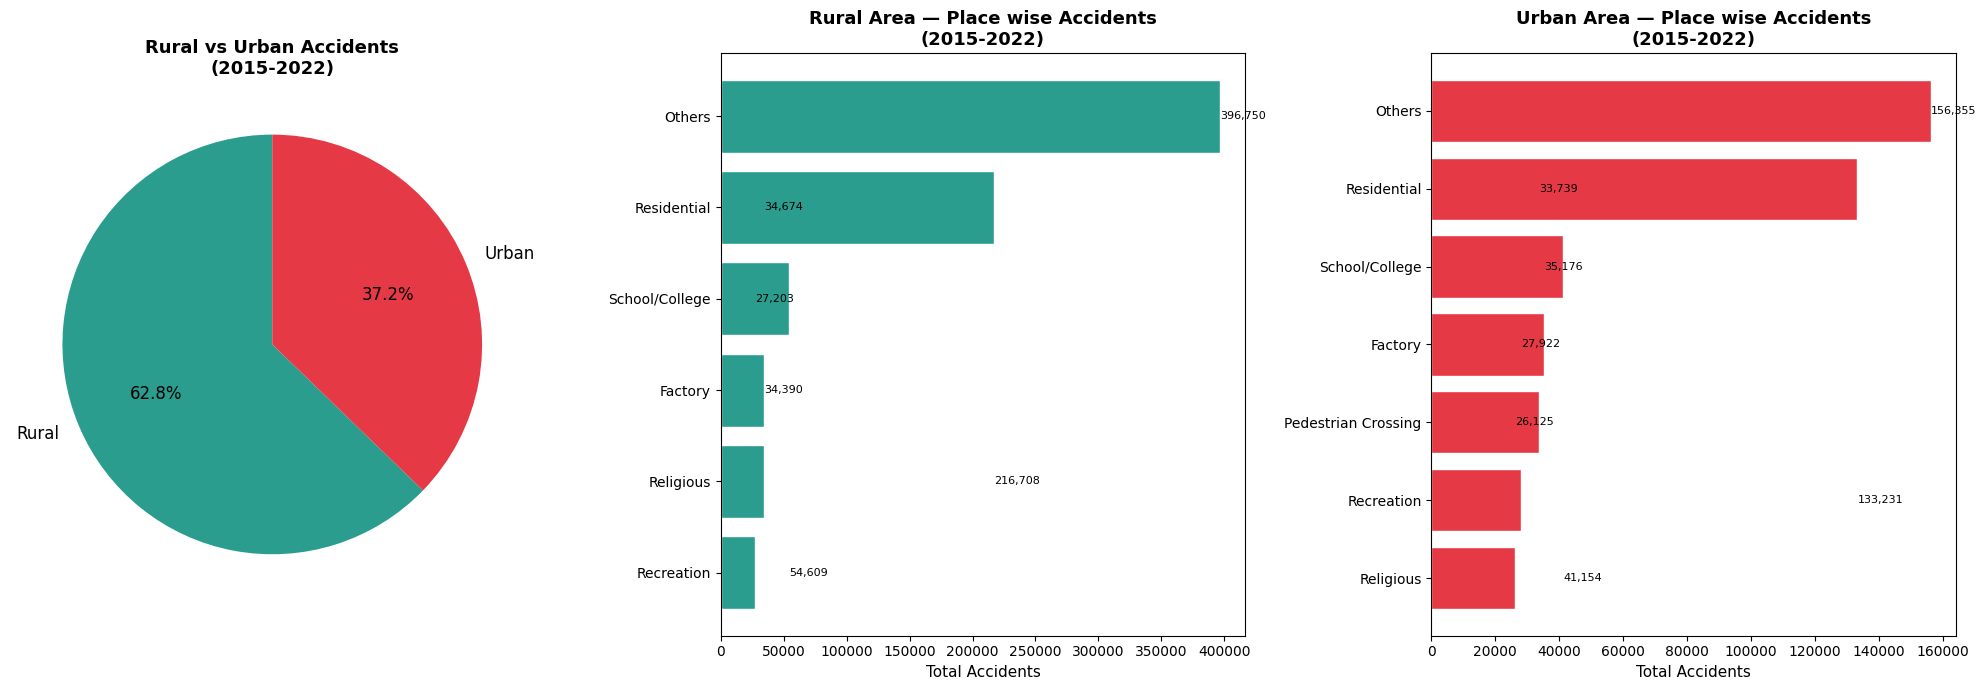


Rural Total: 764,334
Urban Total: 453,702

Rural Breakdown:
  Others: 396,750
  Residential: 216,708
  School/College: 54,609
  Factory: 34,674
  Religious: 34,390
  Recreation: 27,203

Urban Breakdown:
  Others: 156,355
  Residential: 133,231
  School/College: 41,154
  Factory: 35,176
  Pedestrian Crossing: 33,739
  Recreation: 27,922
  Religious: 26,125


In [14]:
# Place of Occurrence Analysis
# Rural vs Urban comparison
rural_total = place_df["Rural Area - Sub Total"].sum()
urban_total = place_df["Urban Area - Sub Total"].sum()

# Detailed breakdown
rural_cols = {
    "School/College": "Rural Area - School/College - Total",
    "Residential": "Rural Area - Residential - Total",
    "Religious": "Rural Area - Religious - Total",
    "Recreation": "Rural Area - Recreation - Total",
    "Factory": "Rural Area - Factory - Total",
    "Others": "Rural Area - Others - Total"
}

urban_cols = {
    "School/College": "Urban Area - School/College - Total",
    "Residential": "Urban Area - Residential - Total",
    "Religious": "Urban Area - Religious - Total",
    "Recreation": "Urban Area - Recreation - Total",
    "Factory": "Urban Area - Factory - Total",
    "Pedestrian Crossing": "Urban Area - Pedestrian Crossing - Total",
    "Others": "Urban Area - Others - Total"
}

rural_data = {k: place_df[v].sum() for k, v in rural_cols.items()}
urban_data = {k: place_df[v].sum() for k, v in urban_cols.items()}

# Plot — 3 charts
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

# Chart 1 — Rural vs Urban Pie
ax1.pie([rural_total, urban_total], 
        labels=["Rural", "Urban"],
        colors=["#2a9d8f", "#e63946"],
        autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 12})
ax1.set_title("Rural vs Urban Accidents\n(2015-2022)", 
              fontsize=13, fontweight="bold")

# Chart 2 — Rural breakdown
rural_df_plot = pd.DataFrame(list(rural_data.items()), 
                              columns=["Place", "Total"])
rural_df_plot = rural_df_plot.sort_values("Total", ascending=True)
ax2.barh(rural_df_plot["Place"], rural_df_plot["Total"], 
         color="#2a9d8f", edgecolor="white")
for i, (place, val) in rural_df_plot.iterrows():
    ax2.text(val + 100, i, f"{int(val):,}", va="center", fontsize=8)
ax2.set_title("Rural Area — Place wise Accidents\n(2015-2022)", 
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Total Accidents", fontsize=11)

# Chart 3 — Urban breakdown
urban_df_plot = pd.DataFrame(list(urban_data.items()), 
                              columns=["Place", "Total"])
urban_df_plot = urban_df_plot.sort_values("Total", ascending=True)
ax3.barh(urban_df_plot["Place"], urban_df_plot["Total"], 
         color="#e63946", edgecolor="white")
for i, (place, val) in urban_df_plot.iterrows():
    ax3.text(val + 100, i, f"{int(val):,}", va="center", fontsize=8)
ax3.set_title("Urban Area — Place wise Accidents\n(2015-2022)", 
              fontsize=13, fontweight="bold")
ax3.set_xlabel("Total Accidents", fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nRural Total: {rural_total:,}")
print(f"Urban Total: {urban_total:,}")
print(f"\nRural Breakdown:")
for k, v in sorted(rural_data.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k}: {v:,}")
print(f"\nUrban Breakdown:")
for k, v in sorted(urban_data.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k}: {v:,}")

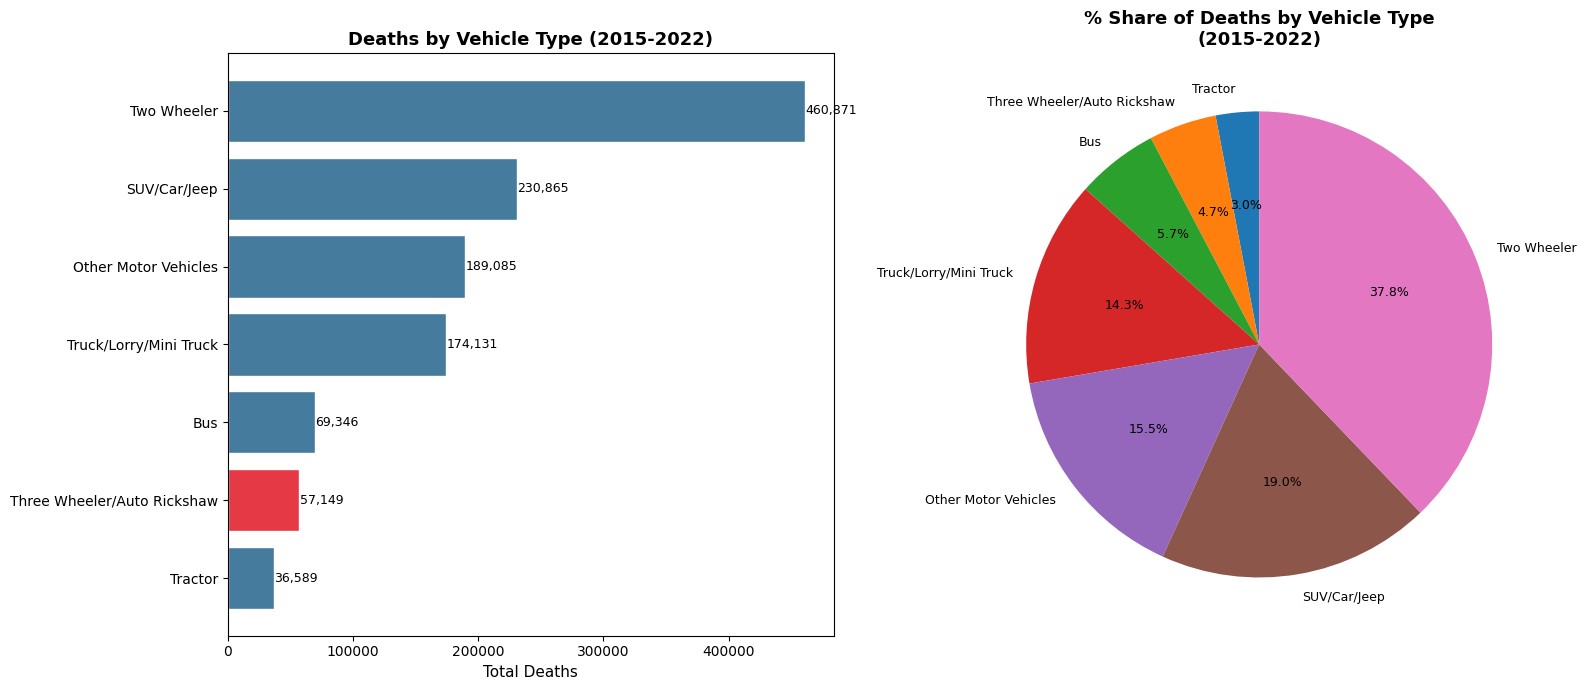


Vehicle wise totals:
               Vehicle Type  Total Deaths
                Two Wheeler        460871
               SUV/Car/Jeep        230865
       Other Motor Vehicles        189085
     Truck/Lorry/Mini Truck        174131
                        Bus         69346
Three Wheeler/Auto Rickshaw         57149
                    Tractor         36589


In [15]:
# Mode of Transport Analysis
transport_cols = [
    "Truck/Lorry/Mini Truck - Died",
    "Bus - Died",
    "SUV/Car/Jeep - Died",
    "Tractor - Died",
    "Three Wheeler/Auto Rickshaw - Died",
    "Two Wheeler - Died",
    "Other Motor Vehicles - Died"
]

# Total deaths per vehicle type
transport_totals = transport_df[transport_cols].sum().reset_index()
transport_totals.columns = ["Vehicle Type", "Total Deaths"]

# Clean names
transport_totals["Vehicle Type"] = transport_totals["Vehicle Type"].str.replace(" - Died", "")

# Sort
transport_totals = transport_totals.sort_values("Total Deaths", ascending=True)

# Colors — Two Wheeler highlight
colors = ["#457b9d", "#457b9d", "#457b9d", "#457b9d", 
          "#457b9d", "#e63946", "#457b9d"]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart
bars = ax1.barh(transport_totals["Vehicle Type"], transport_totals["Total Deaths"],
                color=colors[::-1], edgecolor="white")
for bar, val in zip(bars, transport_totals["Total Deaths"]):
    ax1.text(val + 500, bar.get_y() + bar.get_height()/2,
             f"{int(val):,}", va="center", fontsize=9)
ax1.set_title("Deaths by Vehicle Type (2015-2022)", 
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Total Deaths", fontsize=11)

# Pie chart
ax2.pie(transport_totals["Total Deaths"], 
        labels=transport_totals["Vehicle Type"],
        autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 9})
ax2.set_title("% Share of Deaths by Vehicle Type\n(2015-2022)", 
              fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nVehicle wise totals:")
print(transport_totals.sort_values("Total Deaths", ascending=False).to_string(index=False))